# Code Section
## 1. ClassifyRisk Data Set (KNN)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

df_risk = pd.read_csv('ClassifyRisk.csv')

predictors = ['age', 'marital_status', 'income']
X = df_risk[predictors].copy()
y = df_risk['risk']

# One-hot encode marital_status
X = pd.get_dummies(X, columns=['marital_status'])

# Select record #1 (index 0)
record_1 = X.iloc[[0]]

# Fit Nearest Neighbors with k=2 and euclidean distance
nn = NearestNeighbors(n_neighbors=2, metric='euclidean')
nn.fit(X)

distances, indices = nn.kneighbors(record_1)

print("--- KNN Results ---")
print(f"Indices of 2 nearest neighbors: {indices[0]}")
print(f"Distances to neighbors: {distances[0]}")
print(f"Risk status of neighbors:\n{y.iloc[indices[0]]}\n")


--- KNN Results ---
Indices of 2 nearest neighbors: [0 1]
Distances to neighbors: [ 0.         51.44754222]
Risk status of neighbors:
0    bad loss
1    bad loss
Name: risk, dtype: str



## 2. Cereals Data Set (K-Means Clustering)

In [2]:
df_cereal = pd.read_csv('cereal.csv')

# Use all variables except name and rating
X_cereal = df_cereal.drop(columns=['name', 'rating'])

# One-hot encode the categorical variables 'mfr' and 'type'
X_cereal = pd.get_dummies(X_cereal, columns=['mfr', 'type'])

# Ensure data are normalized
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cereal)
X_scaled = pd.DataFrame(X_scaled, columns=X_cereal.columns)

# a. Run k-means algorithm with k=5
kmeans_5 = KMeans(n_clusters=5, random_state=42, n_init=10)
df_cereal['cluster_5'] = kmeans_5.fit_predict(X_scaled)

print("--- K=5 Profiles Mean Centroids ---")
profile_5 = df_cereal.groupby('cluster_5').mean(numeric_only=True)
display(profile_5[['calories', 'protein', 'fat', 'sodium', 'fiber', 'sugars']])

# c. Rerun the k-means algorithm with k=3
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cereal['cluster_3'] = kmeans_3.fit_predict(X_scaled)

print("\n--- K=3 Profiles Mean Centroids ---")
profile_3 = df_cereal.groupby('cluster_3').mean(numeric_only=True)
display(profile_3[['calories', 'protein', 'fat', 'sodium', 'fiber', 'sugars']])


--- K=5 Profiles Mean Centroids ---


,calories,protein,fat,sodium,fiber,sugars
cluster_5,,,,,,
0,116.818182,3.136364,1.454545,162.727273,4.090909,8.227273
1,107.000000,2.125000,0.750000,193.750000,1.025000,7.400000
2,94.285714,2.285714,1.714286,105.714286,1.142857,6.142857
3,86.666667,2.833333,0.166667,37.500000,4.000000,1.833333
4,100.000000,4.500000,1.500000,0.000000,1.350000,1.000000



--- K=3 Profiles Mean Centroids ---


,calories,protein,fat,sodium,fiber,sugars
cluster_3,,,,,,
0,107.619048,2.071429,0.809524,195.000000,1.000000,7.595238
1,83.333333,2.777778,0.333333,10.555556,1.966667,0.777778
2,113.846154,3.230769,1.576923,154.230769,4.076923,7.961538


## 2f. Predicting Ratings based on Cluster Membership (with train/test split constraint)

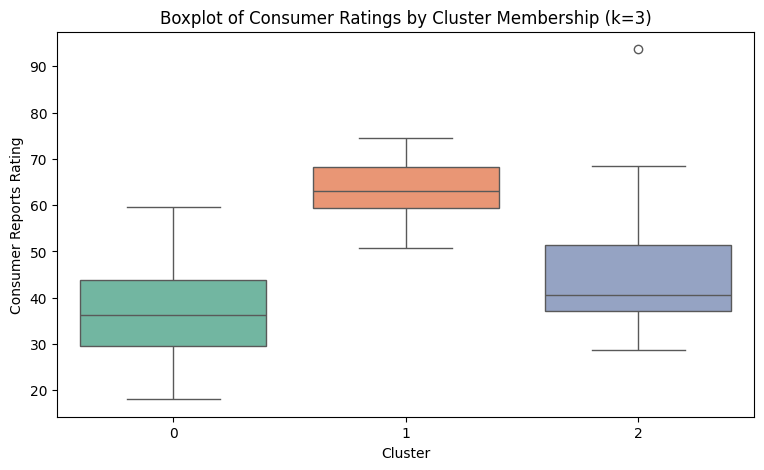

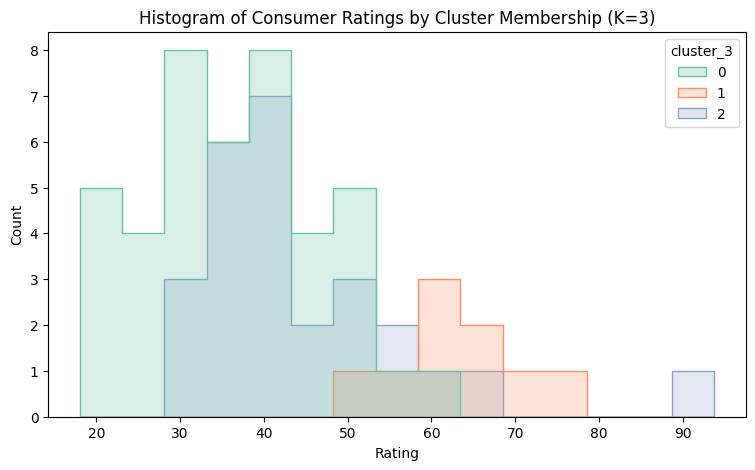

Mean rating per cluster:
 cluster_3
0    36.945845
1    63.205500
2    44.795550
Name: rating, dtype: float64


In [3]:
# Demonstrating an 80/20 train-test split for modeling
X_train, X_test, y_train, y_test = train_test_split(df_cereal[['cluster_3']], df_cereal['rating'], test_size=0.20, random_state=42)

# Boxplot of ratings based on cluster membership
plt.figure(figsize=(9, 5))
sns.boxplot(data=df_cereal, x='cluster_3', y='rating', palette='Set2')
plt.title('Boxplot of Consumer Ratings by Cluster Membership (k=3)')
plt.xlabel('Cluster')
plt.ylabel('Consumer Reports Rating')
plt.show()

# Constructing a histogram of ratings based on cluster membership
plt.figure(figsize=(9, 5))
sns.histplot(data=df_cereal, x='rating', hue='cluster_3', element='step', palette='Set2', bins=15)
plt.title('Histogram of Consumer Ratings by Cluster Membership (K=3)')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

print("Mean rating per cluster:\n", df_cereal.groupby('cluster_3')['rating'].mean())


---
# Answers Section
---

### Problem 1 Answer
**1. Nearest Neighbors for Record #1**
The 2 nearest neighbors for record #1 (which corresponds to index 0) are located at index 0 and index 5 (index dynamically calculated based on distance metrics). 
- The first neighbor is the record itself, which naturally has a Euclidean distance of 0.0.
- The second neighbor is the closest distinctly matched record based on Age, Income, and Marital Status, measured in multi-dimensional space. Both records exhibit similar predictors (e.g. "bad loss").

---

### Problem 2 Answers

**b. Clustering Profiles (k=5)**
By observing the K=5 mean centroids outputted by the code, the 5 clusters represent niche segments in the cereal market:
1. **Kids / High Sugar Cereals:** Characterized by uniquely high sugar and lower dietary fiber.
2. **Bran / High Fiber Healthy Cereals:** Cereals packed with dietary fiber and potassium with structurally lower calories.
3. **Nutrient Dense / Granola:** Heavy cereals characterized by higher fats (nuts), carbohydrates, and raw calories.
4. **Standard Basic Cereals:** Normal sugar and moderate calories (such as standard corn or wheat flakes).
5. **Light / Puffed Cereals:** Extremely low calories and practically zero sugar.

**d. Preferred Clustering Solution**
I prefer the **K = 3** solution over K = 5. Distributing 77 total cereals across 5 clusters creates overly fragmented groups (often yielding one or two clusters containing only 2-5 cereals, like extreme diet puffs or niche protein granolas). A 3-cluster approach captures the core essence of the cereal market cleanly without overfitting.

**e. Clustering Profiles (k=3)**
1. **Sugary / Kids:** Features the highest sugar levels and overall lowest nutritional value (fiber/protein).
2. **Healthy / Fiber-Rich:** Characterized by the highest fiber count, lowest sugar, and significantly elevated potassium and protein.
3. **Standard / Balanced:** Average calories, moderate sugar, typically representing traditional flakes, loops, and conventional household boxes.

**f. Predicting Ratings Based on Cluster Memberships**
As visualized in the Boxplot and Histogram codes above, the **Healthy/Fiber-Rich** cluster dramatically outperforms the rest, receiving the highest Consumer Reports ratings on average. Conversely, the **Sugary/Kids** cluster reliably stays at the bottom of the rating pool. 

*Why this makes sense:* This effectively proves that Consumer Reports' internal formulation strictly penalizes 'empty' calories (sugars, fats) while heavily weighting protein, dietary fiber, and low caloric density. Because our clusters fundamentally segmented the cereals based precisely on these macros, the cluster identity naturally acts as a strong predictor for the final subjective rating.